# EDA
El objetivo es conseguir responder a estas preguntas: 

1. ¿A qué edad alcanzan el pico de rendimiento los atletas (medido con Dots) y difiere entre hombres y mujeres?
2. ¿Cómo progresan los atletas dentro de una competición? ¿Suben de peso entre intentos 1 → 2 → 3 o tienden a repetir/bajar?
3. ¿En qué levantamiento (squat, bench, deadlift) se producen más fallos en el 3er intento?
4. ¿Los atletas que compiten en más eventos full lifting rinden más o menos que los que se especializan en un sólo tipo de levantamiento?
5. ¿El 4º intento permite a los atletas superar su mejor marca de los 3 primeros? ¿Cuál es la tasa de éxito?

Para ello, haremos un filtrado antes si quiera de explorar los datos, ya que gracias a OPL_guide tengo contexto de todas las columnas. Después, exploraré, limpiaré y finalmente analizaré el dataset.

## 1. Importar librerías

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 2. Set Up

### Condiciones del display
El objetivo es que todos los display se vean iguales y obligarlo a mostrar todas las columnas para poder visualizar mejor los datos.

In [3]:
# Mostrar todas las columnas (sin cortar)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Mostrar decimales con 2 cifras nada más.
pd.set_option('display.float_format', '{:.2f}'.format)

### Cargar el dataset
Además de cargar el archivo, voy a eliminar directamente algunas columnas que sé que no voy a utilizar para reducir el volumen de datos, que con un dataset tan grande, es importante. Además, cómo la idea es que los resultados sean lo más útiles y aplicables posible, voy a filtrar el dataset por `Sanctioned` y `Tested`, con la idea de asegurarme que era una competición oficial y que además, _a priori_, los atletas no consumen sustancias dopantes.

Las columnas eliminadas de primeras son:

- `Country`, `State`, `MeetState`, `MeetTown`, `MeetCountry`, `ParentFederation`, `MeetName`, `Division`: Información excesiva sobre la competición o participante (especialmente nombres y localización) que no voy a utilizar.
- `Sanctioned` y `Tested`: Una vez filtrado el df por estas columnas, no las necesito para nada más.

In [4]:
opl_df = pd.read_csv('../data/OPL_dataset.csv', low_memory = False)

filtered_df = opl_df[(opl_df['Sanctioned'] == 'Yes') & (opl_df['Tested'] == 'Yes')]

filtered_df = filtered_df.drop(columns = ['Country', 'State', 'MeetState', 'MeetTown', 'MeetCountry', 'ParentFederation', 'MeetName', 'Division', 'Sanctioned', 'Tested'])

## 3. Explorar el dataset

### 3.1. Exploración general

In [5]:
display(filtered_df.head())

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,BodyweightKg,WeightClassKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Glossbrenner,Goodlift,Federation,Date
726,Maysar Olaymi,M,B,Raw,24.00,24-34,24-39,43.50,49,NaN,NaN,NaN,NaN,NaN,-85.00,85.00,91.00,NaN,91.00,NaN,NaN,NaN,NaN,NaN,91.00,1,104.83,109.30,108.45,65.25,WPPO,2017-02-21
727,Mohammad Alshnaiti,M,B,Raw,15.00,13-15,14-18,39.50,49,NaN,NaN,NaN,NaN,NaN,70.00,-80.00,-80.00,NaN,70.00,NaN,NaN,NaN,NaN,NaN,70.00,2,88.98,93.48,92.70,53.03,WPPO,2017-02-21
728,Ali Alzeyoudi,M,B,Raw,14.00,13-15,14-18,47.50,49,NaN,NaN,NaN,NaN,NaN,-26.00,-26.00,-26.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,WPPO,2017-02-21
729,Osama Albalushi,M,B,Raw,14.00,13-15,14-18,53.95,54,NaN,NaN,NaN,NaN,NaN,-64.00,-64.00,-64.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,WPPO,2017-02-21
730,Ali Al-Darraji,M,B,Raw,35.00,35-39,24-39,52.30,54,NaN,NaN,NaN,NaN,NaN,135.00,140.00,142.00,NaN,142.00,NaN,NaN,NaN,NaN,NaN,142.00,1,135.27,138.51,136.36,91.68,WPPO,2017-02-21


### 3.2. Filas, columnas y tipos

In [6]:
filtered_df.info()
print("---------------------------------------")
print(f"Número de filas: {filtered_df.shape[0]}")
print(f"Número de columnas: {filtered_df.shape[1]}")

<class 'pandas.DataFrame'>
Index: 2984277 entries, 726 to 3920661
Data columns (total 32 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Name             str    
 1   Sex              str    
 2   Event            str    
 3   Equipment        str    
 4   Age              float64
 5   AgeClass         str    
 6   BirthYearClass   str    
 7   BodyweightKg     float64
 8   WeightClassKg    str    
 9   Squat1Kg         float64
 10  Squat2Kg         float64
 11  Squat3Kg         float64
 12  Squat4Kg         float64
 13  Best3SquatKg     float64
 14  Bench1Kg         float64
 15  Bench2Kg         float64
 16  Bench3Kg         float64
 17  Bench4Kg         float64
 18  Best3BenchKg     float64
 19  Deadlift1Kg      float64
 20  Deadlift2Kg      float64
 21  Deadlift3Kg      float64
 22  Deadlift4Kg      float64
 23  Best3DeadliftKg  float64
 24  TotalKg          float64
 25  Place            str    
 26  Dots             float64
 27  Wilks            float64
 

### 3.3. Estadística de las variables

In [7]:
print("----------------- ANÁLISIS VARIABLES NUMÉRICAS -----------------")
display(filtered_df.describe())


print("----------------- ANÁLISIS VARIABLES CATEGÓRICAS -----------------")
print(" 1. Sexo")
display(filtered_df['Sex'].value_counts())

print(" 2. Levantamientos realizados")
display(filtered_df['Event'].value_counts())

print(" 3. Equipamiento permitido")
display(filtered_df['Equipment'].value_counts())

print(" 4. Podium")
display(filtered_df['Place'].value_counts())

print(" 5. Federación")
display(filtered_df['Federation'].value_counts())

----------------- ANÁLISIS VARIABLES NUMÉRICAS -----------------


,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Dots,Wilks,Glossbrenner,Goodlift
count,1771332.00,2955982.00,965849.00,956926.00,936767.00,4514.00,2204301.00,1348467.00,1335278.00,1302498.00,11925.00,2690344.00,1035759.00,1020532.00,989807.00,13862.00,2294029.00,2768811.00,2756977.00,2756977.00,2756977.00,2586604.00
mean,29.87,82.10,116.64,104.10,46.69,94.04,164.97,81.06,58.27,-10.20,50.43,108.65,158.24,136.52,28.58,112.47,179.61,377.70,283.69,282.63,265.11,62.54
std,13.45,22.51,125.20,147.72,180.95,150.56,63.14,88.09,111.75,129.48,137.44,49.06,100.64,145.63,205.48,152.62,59.67,191.10,120.11,119.64,113.73,15.89
min,0.00,15.10,-477.50,-500.00,-525.00,-462.50,-440.00,-635.50,-635.50,-575.00,-440.00,-362.50,-500.00,-502.50,-587.50,-405.00,-400.00,1.00,0.68,0.67,0.64,0.50
25%,19.50,65.60,92.50,87.50,-140.00,70.00,115.67,57.47,40.00,-122.50,-70.00,70.00,125.00,120.00,-192.50,100.00,132.50,222.50,198.78,198.15,181.48,50.85
50%,25.50,80.29,145.00,145.00,120.00,130.00,160.00,97.50,90.00,-52.50,85.05,105.00,175.00,175.00,127.50,147.87,176.90,362.50,304.47,303.43,282.34,62.25
75%,37.00,95.89,190.00,200.00,190.00,190.00,206.38,133.00,135.00,112.50,152.50,140.00,220.00,225.00,205.00,205.38,225.00,522.50,370.48,368.88,348.01,73.82
max,105.50,260.20,510.29,537.51,515.00,474.00,537.51,659.00,464.93,635.50,380.00,659.00,410.00,411.00,420.00,380.00,439.98,1296.00,724.07,733.75,666.59,182.71


----------------- ANÁLISIS VARIABLES CATEGÓRICAS -----------------
 1. Sexo


Sex
M     2069217
F      914965
Mx         95
Name: count, dtype: int64

 2. Levantamientos realizados


...

Equipment
Raw           1362600
Single-ply    1195821
Unlimited      314048
Wraps           77111
Multi-ply       34697
Name: count, dtype: int64

 4. Podium


Place
1      1100650
2       459586
3       293132
4       205390
DQ      192715
        ...   
117          1
118          1
119          1
120          1
195          1
Name: count, Length: 125, dtype: int64

 5. Federación


Federation
THSPA           535620
USAPL           359073
THSWPA          325029
FPR             191693
USPA             82585
                 ...  
WPC-France          10
AmericanSA           9
WRPF-Ecuador         9
OceaniaPO            8
WUAP                 3
Name: count, Length: 250, dtype: int64

### 3.4. Nulos y duplicados

In [8]:
print(filtered_df.isnull().sum())
print("--------------------------------------------")
print(f"Nº duplicados: {filtered_df.duplicated().sum()}")

Name                     0
Sex                      0
Event                    0
Equipment                0
Age                1212945
AgeClass            885082
BirthYearClass     1121121
BodyweightKg         28295
WeightClassKg        35146
Squat1Kg           2018428
Squat2Kg           2027351
Squat3Kg           2047510
Squat4Kg           2979763
Best3SquatKg        779976
Bench1Kg           1635810
Bench2Kg           1648999
Bench3Kg           1681779
Bench4Kg           2972352
Best3BenchKg        293933
Deadlift1Kg        1948518
Deadlift2Kg        1963745
Deadlift3Kg        1994470
Deadlift4Kg        2970415
Best3DeadliftKg     690248
TotalKg             215466
Place                    0
Dots                227300
Wilks               227300
Glossbrenner        227300
Goodlift            397673
Federation               0
Date                     0
dtype: int64
--------------------------------------------
Nº duplicados: 59557


# Limpieza de los datos

## 1. Gestión de duplicados
El análisis anterior muestra 59547 duplicados exactos → Eliminarlos [manteniendo uno (cualquiera)].

In [9]:
dp_df = filtered_df.drop_duplicates()

## 2. Gestión de tipos

- Columnas con tipo correcto[tipo actual]: Name `[Str]`, Age `[Float]`, Bodyweight `[Float]`, BenchANY `[Float]`, SquatANY `[Float]`, DeadliftANY `[Float]`, Total `[Float]`, ValoracionesANY `[Float]`.
- Columnas con tipo incorrecto[tipo esperado]: Sex `[Cat]`, Event `[Cat]`, Equipment `[Cat]`, Date `[Date]`, Country `[Cat]`, Federation `[Cat]`, Place `[Cat]`.

### 2.1. Justificación de algunas decisiones
`Country`, `Federation` y `Place` son columnas con +100 posibles valores, lo que me generaba dudas sobre si debería convertirlas o no, pero como el objetivo es reducir espacio de la memoria, simplemente hice los cálculos y ví que el ahorro era tremendo. Consecuentemente, mantuve los cambios.

PD: `AgeClass`, `BrithYearClass` y `WeightClassKg` no han sufrido modificaciones (a pesar de que las necesitan) porque las mantengo en el dataset **solo** para que me ayuden a imputar los datos o a filtrar.

### 2.2. Cambios

In [10]:
# Categorías
types_df = dp_df.copy()
cat_var = ['Sex', 'Event', 'Equipment', 'Federation', 'Place']
types_df[cat_var] = types_df[cat_var].astype('category')

# Fechas
types_df['Date'] = pd.to_datetime(types_df['Date'])

### 2.3. Comprobaciones

In [11]:
print("------------ AHORRO GENERAL ------------")
print(f" Memoria PRE-CLEAN : {dp_df.memory_usage(deep=True).sum()}")
print(f" Memoria POST-CLEAN: {types_df.memory_usage(deep=True).sum()}")

print("\n------------ AHORRO FEDERACIÓN ------------")
print(f"Federación ANTES  : {dp_df['Federation'].memory_usage(deep=True)}")
print(f"Federación DESPUÉS: {types_df['Federation'].memory_usage(deep=True)}")

print("\n------------ AHORRO PODIUM ------------")
print(f"Podium ANTES  : {dp_df['Place'].memory_usage(deep=True)}")
print(f"Podium DESPUÉS: {types_df['Place'].memory_usage(deep=True)}")


print("\n------------ CHECK CAMBIOS ------------")
display(types_df.dtypes)


------------ AHORRO GENERAL ------------
 Memoria PRE-CLEAN : 2087187778
 Memoria POST-CLEAN: 1192651892

------------ AHORRO FEDERACIÓN ------------
Federación ANTES  : 180060595
Federación DESPUÉS: 29260761

------------ AHORRO PODIUM ------------
Podium ANTES  : 170057792
Podium DESPUÉS: 26328867

------------ CHECK CAMBIOS ------------


Name                          str
Sex                      category
Event                    category
Equipment                category
Age                       float64
AgeClass                      str
BirthYearClass                str
BodyweightKg              float64
WeightClassKg                 str
Squat1Kg                  float64
Squat2Kg                  float64
Squat3Kg                  float64
Squat4Kg                  float64
Best3SquatKg              float64
Bench1Kg                  float64
Bench2Kg                  float64
Bench3Kg                  float64
Bench4Kg                  float64
Best3BenchKg              float64
Deadlift1Kg               float64
Deadlift2Kg               float64
Deadlift3Kg               float64
Deadlift4Kg               float64
Best3DeadliftKg           float64
TotalKg                   float64
Place                    category
Dots                      float64
Wilks                     float64
Glossbrenner              float64
Goodlift      

## 3. Gestión de nulos
El principal problema de este dataset es que contiene una grandísima cantidad de nulos en muchas columnas, y encima, muchos de esos nulos son 'correctos'.

Por ello, he tomado la decisión de que rellenaré la mayoría de nulos posibles mientras tenga sentido hacerlo, y después, filtraré el dataframe para cada pregunta concreta que quiera responder de manera que así mantengo el máximo número de datos posibles en cada análisis. Para cada variable explico cómo lo voy a hacer en su apartado concreto.

### 3.1. Gestión de nulos ~ Edad
Voy a aprovechar las columnas de `AgeClass` y `BirthYearClass` para tratar de imputar la mayoría de valores posibles. Una vez utilizadas, las eliminaré porque no me aportan nada más.
1. Como los rangos de `AgeClass` son más pequeños, en caso de que ambas variables estén disponibles, usaré `AgeClass`.
2. La estructura de ambas columnas es `NN-NN`, por lo que basta con separar por `-`, convertir a integer y hacer el promedio de ambos extremos del rango.
3. Para los NaN restantes, para no inventarme la edad usando medias, medianas o modas, filtraré el dataset final en el momento en que vaya a contestar una duda sobre la edad.

In [ ]:
null_df1 = types_df.copy()
print('Filas con Class sin Edad: ', null_df1[null_df1['Age'].isna() & null_df1['AgeClass'].notna()].shape[0])
print('Filas con Bdy_Class sin Edad: ', null_df1[null_df1['Age'].isna() & null_df1['BirthYearClass'].notna()].shape[0])

def age_imputer(fila: pd.Series):

    if pd.isna(fila['Age']):

        if not pd.isna(fila['AgeClass']):                    # Si hay AgeClass, devuelve la media

            nums = fila['AgeClass'].split("-")
            resultado = (int(nums[0]) + int(nums[1]))/2
            
            if resultado > 80:                              # Para evitar que al hacer una categoría se dispare la edad
                return 80
            
            elif resultado < 14:                            # Para evitar que al hacer una categoría se hunda la edad
                return 14
            
            else:
                return resultado
        
        elif not pd.isna(fila['BirthYearClass']):            # Si hay BirthYearClass, devuelve la media

            nums = fila['BirthYearClass'].split("-")

            resultado = (int(nums[0]) + int(nums[1]))/2
            
            if resultado > 80:                              # Para evitar que al hacer una categoría se dispare la edad
                return 80
            
            elif resultado < 14:                            # Para evitar que al hacer una categoría se hunda la edad
                return 14
            
            else:
                return resultado
        
        else:
            return pd.NA
    
    else:
        return fila['Age']

null_df1['Age'] = null_df1.apply(age_imputer, axis = 1)
null_df1 = null_df1.drop(columns = ['AgeClass', 'BirthYearClass'])

print('Nulos pre-IMPUTING : ', types_df['Age'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df1['Age'].isnull().sum())

Filas con Class sin Edad:  325121
Filas con Bdy_Class sin Edad:  132179
Nulos pre-IMPUTING :  1203061
Nulos post-IMPUTING:  828967


### 3.2. Gestión de nulos ~ Métricas
`Wilks`, `Dots`, `Glossbrenner` y `Goodlift[IPF]` son 4 métricas para lo mismo: Estandarizar las cargas levantadas en base al peso del atleta. Dado que `Dots` es la más reciente y utilizada en la actualidad, será la métrica definitiva que utilizaremos. Las otras 3 las utilizaré para imputar y después las eliminaré.

1. Dado que 3 de ellas tienen sorprendentemente los mismos nulos, comprobaré que no sean en las mismas filas.
2. Calcularé la correlación entre las `Dots` y las otras 3 variables para ver cuál correlaciona mejor con ella.
3. Una vez calculada las correlaciones, imputaré los valores dando prioridad a aquellas con mayor coeficiente.
4. Para los NaN restantes, para no inventarme `Dots` usando medias, medianas o modas, filtraré el dataset final en el momento en que vaya a contestar una duda con la métrica.

In [40]:
null_df2 = null_df1.copy()

print('Filas con Wilks sin Dots: ', null_df2[null_df2['Dots'].isna() & null_df2['Wilks'].notna()].shape[0])
print('Filas con Glossbrenner sin Dots:', null_df2[null_df2['Dots'].isna() & null_df2['Glossbrenner'].notna()].shape[0])
print('Filas con Goodlift sin Dots: ', null_df2[null_df2['Dots'].isna() & null_df2['Goodlift'].notna()].shape[0])

null_df2 = null_df2.drop(columns = ['Wilks', 'Glossbrenner', 'Goodlift'])

Filas con Wilks sin Dots:  0
Filas con Glossbrenner sin Dots: 0
Filas con Goodlift sin Dots:  0


Cómo no existe ni una sola fila donde falte Dots y esté presente alguna de las otras métricas, simplemente elimino las otras columnas y mantengo los NaNs, que serán filtrados a la hora de contestar la pregunta pertinente.

### 3.3. Gestión de nulos ~ Peso corporal
Repito la misma idea que hasta ahora, la idea es usar `WeightClassKg` para imputar `BodyweightKg`, y una vez imputado todo lo posible, eliminar dicha columna. Al igual que ha ocurrido con la edad, si quedan NaN, se filtrará en la respuesta a la pregunta pertinente para no perder datos para el resto de preguntas.

El formato de `WeightClassKg` es `NN` (_up to `NN`_) o `NN+` (_from `NN` on_). Por lo que la idea es:
1. Extraer el número.
2. Redondearlo en caso de que sea decimal.
3. Utilizarlo para imputar.
4. He observado que un par de valores tienen el siguiente formato `-NN`, que como no se detalla en la guía, los consideraré un error, y por tanto, no los usaré para imputar.

In [41]:
null_df3 = null_df2.copy()

print('Filas con Clase sin Peso: ', null_df3[null_df3['BodyweightKg'].isna() & null_df3['WeightClassKg'].notna()].shape[0])

def weight_imputer(fila: pd.Series):

    if pd.isna(fila['BodyweightKg']):
        
        # Si hay WeightClassKg, devuelve ese valor
        if not pd.isna(fila['WeightClassKg']) and not fila['WeightClassKg'].startswith('-') and any(c.isdigit() for c in fila['WeightClassKg']):

            num = float(fila['WeightClassKg'].rstrip("+"))
            return num
        
        else:
            return pd.NA
    
    else:
        return fila['BodyweightKg']

null_df3['BodyweightKg'] = null_df3.apply(weight_imputer, axis = 1)
null_df3 = null_df3.drop(columns = ['WeightClassKg'])

print('Nulos pre-IMPUTING : ', types_df['BodyweightKg'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df3['BodyweightKg'].isnull().sum())

Filas con Clase sin Peso:  10250
Nulos pre-IMPUTING :  27482
Nulos post-IMPUTING:  17233


### 3.4. Gestión de nulos ~ Levantamientos
Todas las columnas referidas a los pesos levantados en cada uno de los intentos para Squat, Bench y Deadlift contienen nulos, pero son nulos válidos porque el atleta no participó en dicho levantamiento. El problema de estas columnas es que tienen valores negativos para denotar los intentos fallidos, pero eso se limpiará más adelante.

Otro punto son los Best3LIFT, donde es posible que haya valores nulos a pesar de que alguno de los 3 intentos sea valido. Voy a comprobarlo, y en caso de que haya, rellenarlo con el valor más alto de los que haya disponible.

In [42]:
null_df4 = null_df3.copy()

print('Filas con LIFTS sin TOTAL en BENCH   : ' , null_df4[null_df4['Best3BenchKg'].isna() & (null_df4['Bench1Kg'].notna() | null_df4['Bench2Kg'].notna() | null_df4['Bench3Kg'].notna())].shape[0])
print('Filas con LIFTS sin TOTAL en Squat   : ' , null_df4[null_df4['Best3SquatKg'].isna() & (null_df4['Squat1Kg'].notna() | null_df4['Squat2Kg'].notna() | null_df4['Squat3Kg'].notna())].shape[0])
print('Filas con LIFTS sin TOTAL en DEADLIFT: ' , null_df4[null_df4['Best3DeadliftKg'].isna() & (null_df4['Deadlift1Kg'].notna() | null_df4['Deadlift2Kg'].notna() | null_df4['Deadlift3Kg'].notna())].shape[0])
print("---------------------------------------------------------")

def best_imputer(lift1: pd.Series, lift2: pd.Series, lift3: pd.Series, best_lift: pd.Series):

    lifts = []

    if pd.isna(best_lift):
        
        if pd.notna(lift1) and lift1 > 0:
            lifts.append(lift1)

        if pd.notna(lift2) and lift2 > 0:
            lifts.append(lift2)

        if pd.notna(lift3) and lift3 > 0:
            lifts.append(lift3)

        if len(lifts) > 0:
            print("lifts:", lifts)
            return max(lifts)
        
        else:
            return pd.NA
    
    else:
        return best_lift

null_df4['Best3BenchKg'] = null_df4.apply(lambda fila: best_imputer(fila['Bench1Kg'], fila['Bench2Kg'], fila['Bench3Kg'], fila['Best3BenchKg']), axis=1)
null_df4['Best3SquatKg'] = null_df4.apply(lambda fila: best_imputer(fila['Squat1Kg'], fila['Squat2Kg'], fila['Squat3Kg'], fila['Best3SquatKg']), axis=1)
null_df4['Best3DeadliftKg'] = null_df4.apply(lambda fila: best_imputer(fila['Deadlift1Kg'], fila['Deadlift2Kg'], fila['Deadlift3Kg'], fila['Best3DeadliftKg']), axis=1)

print('Nulos pre-IMPUTING en BENCH : ', null_df3['Best3BenchKg'].isnull().sum())
print('Nulos post-IMPUTING en BENCH: ', null_df4['Best3BenchKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulos pre-IMPUTING en Squat : ', null_df3['Best3SquatKg'].isnull().sum())
print('Nulos post-IMPUTING en Squat: ', null_df4['Best3SquatKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulos pre-IMPUTING en DEADL : ', null_df3['Best3DeadliftKg'].isnull().sum())
print('Nulos post-IMPUTING en DEADL: ', null_df4['Best3DeadliftKg'].isnull().sum())

Filas con LIFTS sin TOTAL en BENCH   :  34440
Filas con LIFTS sin TOTAL en Squat   :  18439
Filas con LIFTS sin TOTAL en DEADLIFT:  9855
---------------------------------------------------------
Nulos pre-IMPUTING en BENCH :  284208
Nulos post-IMPUTING en BENCH:  284208
---------------------------------------------------------
Nulos pre-IMPUTING en Squat :  751829
Nulos post-IMPUTING en Squat:  751829
---------------------------------------------------------
Nulos pre-IMPUTING en DEADL :  671887
Nulos post-IMPUTING en DEADL:  671887


In [43]:
null_df4[null_df4['Best3BenchKg'].isna() & (null_df4['Bench1Kg'].notna() | null_df4['Bench2Kg'].notna() | null_df4['Bench3Kg'].notna())][['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Best3BenchKg']].head(20)

,Bench1Kg,Bench2Kg,Bench3Kg,Best3BenchKg
728,-26.00,-26.00,-26.00,<NA>
729,-64.00,-64.00,-64.00,<NA>
757,-96.00,-98.00,-98.00,<NA>
924,-100.00,-100.00,-110.00,<NA>
925,-140.00,-140.00,-140.00,<NA>
926,-163.00,-163.00,-163.00,<NA>
947,-130.00,-135.00,-135.00,<NA>
948,-145.00,-145.00,-150.00,<NA>
949,-170.00,-170.00,-173.00,<NA>
970,-145.00,-145.00,-145.00,<NA>


Tras la ejecución de la celda comprobé que los resultados eran extraños. La primera comprobación mostraba que existían filas donde había valores de algunos lifts, sin haber best3lift. Sin embargo, tras la ejecución de la función, ni un sólo NaN en best3lift se había rellenado. Así que, tras tiempo pensando, llegué a la conclusión de que quizá había valores, pero eran negativos. Y eso es justo lo que compruebo en la celda anterior.

Ahora, voy a comprobar lo mismo para TotalKg [Bench + Squat + Deadlift]. Si nuevamente para cuando TotalKg es NaN, las 3 columnas de best_lift son NaN o negativas, dejaré TotalKg tal cual. Sino, lo rellenaré con la suma de los 3 levantamientos.

In [44]:
null_df5 = null_df4.copy()

print('Filas con BEST_LIFTS sin TOTAL: ', null_df4[null_df4['TotalKg'].isna() & (null_df4['Best3DeadliftKg'].notna() & null_df4['Best3SquatKg'].notna() & null_df4['Best3BenchKg'].notna())].shape[0])

def total_imputer(bench: pd.Series, squat: pd.Series, deadlift: pd.Series, total_lift: pd.Series):

    if pd.isna(total_lift):
        
        if pd.notna(bench) and pd.notna(squat) and pd.notna(deadlift):
            return bench + squat + deadlift
        
        else:
            return pd.NA
    
    else:
        return total_lift
    
null_df5['TotalKg'] = null_df5.apply(lambda fila: total_imputer(fila['Best3BenchKg'], fila['Best3SquatKg'], fila['Best3DeadliftKg'], fila['TotalKg']), axis=1)

print('Nulos pre-IMPUTING : ', null_df4['TotalKg'].isnull().sum())
print('Nulos post-IMPUTING: ', null_df5['TotalKg'].isnull().sum())

Filas con BEST_LIFTS sin TOTAL:  6646
Nulos pre-IMPUTING :  211235
Nulos post-IMPUTING:  204589


## 4. Limpieza de datos

### 4.1. Sexo
En este dataframe se contempla la categoría `Mx` para considerar a personas no binarias. Dado el bajo número de registros de esta categoría y que, a nivel biológico, el sexo es diferencial dado las variaciones hormonales, voy a eliminar dicha categoría y sus registros.

In [70]:
clean_df = null_df5.copy()

clean_df = clean_df[clean_df['Sex'] != 'Mx']

clean_df['Sex'] = clean_df['Sex'].cat.remove_unused_categories()

clean_df['Sex'].cat.categories

Index(['F', 'M'], dtype='str')

### 4.2. Levantamientos fallidos: Si o No
Dadas las necesidades de las preguntas, voy a crear una nueva columna booleana para capturar si el tercer y cuarto intento ha sido éxito o fallo, y después, voy a transformar todos los negativos en NaN, para que, a la hora de responder la pregunta pertinente, al eliminar los NaN, se vayan los values negativos también, ya que estos indican un fallo en el levantamiento, y por tanto, no dan información.

In [71]:
# Tercer intento bool
clean_df['Bench3bool'] = np.where(pd.notna(clean_df['Bench3Kg']), np.where(clean_df['Bench3Kg'] > 0, True, False), pd.NA)
clean_df['Squat3bool'] = np.where(pd.notna(clean_df['Squat3Kg']), np.where(clean_df['Squat3Kg'] > 0, True, False), pd.NA)
clean_df['Deadlift3bool'] = np.where(pd.notna(clean_df['Deadlift3Kg']), np.where(clean_df['Deadlift3Kg'] > 0, True, False), pd.NA)

# Cuarto intento bool
clean_df['Bench4bool'] = np.where(pd.notna(clean_df['Bench4Kg']), np.where(clean_df['Bench4Kg'] > 0, True, False), pd.NA)
clean_df['Squat4bool'] = np.where(pd.notna(clean_df['Squat4Kg']), np.where(clean_df['Squat4Kg'] > 0, True, False), pd.NA)
clean_df['Deadlift4bool'] = np.where(pd.notna(clean_df['Deadlift4Kg']), np.where(clean_df['Deadlift4Kg'] > 0, True, False), pd.NA)

cols_with_neg = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg']

for col in cols_with_neg:

    clean_df.loc[clean_df[col] <= 0, col] = np.nan

# Análisis ~ Respuesta a las preguntas

## Pregunta 1

### ¿A qué edad alcanzan el pico de rendimiento los atletas (medido con Dots) y difiere entre hombres y mujeres?

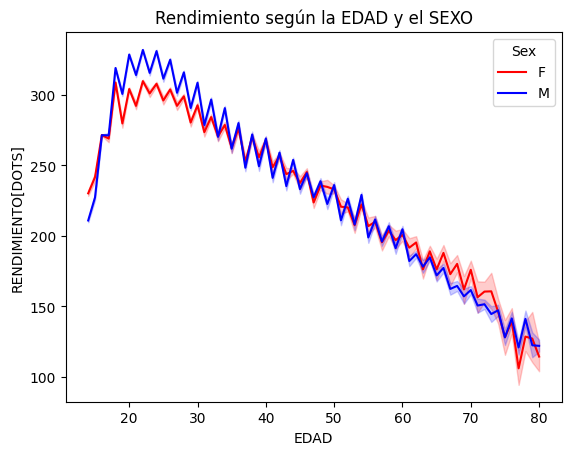

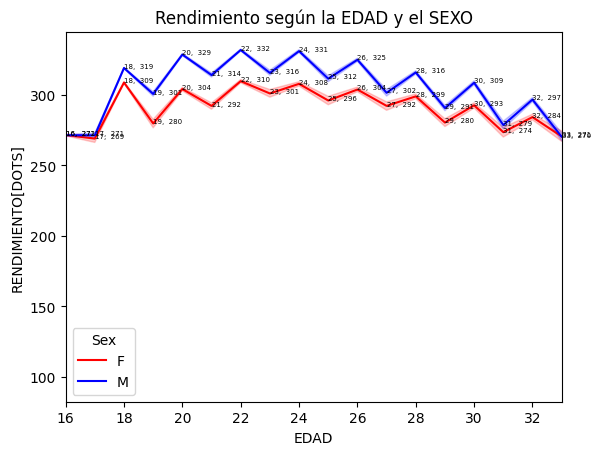

In [96]:
# Terminamos de limpiar para la pregunta concreta:
q1_df = clean_df.dropna(subset = ['Age', 'Dots'])

# Filtramos por edades lógicas
q1_df = q1_df[(q1_df['Age'] >= 14) & (q1_df['Age'] <= 80)]

# Plot
fig, ax = plt.subplots()
ax.set_title("Rendimiento según la EDAD y el SEXO")
ax.set_xlabel("EDAD")
ax.set_ylabel("RENDIMIENTO[DOTS]")

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'red',
            'M': 'blue'
            },
        ax = ax
		)

# Output numérico exacto
fig, ax = plt.subplots()
ax.set_title("Rendimiento según la EDAD y el SEXO")
ax.set_xlabel("EDAD")
ax.set_ylabel("RENDIMIENTO[DOTS]")
ax.set_xlim(16, 33)

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'red',
            'M': 'blue'
            },
        ax = ax
		)

for line in ax.lines:           # Poner tags en el zoom para ver edad exacta
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f'{x:.0f}, {y: .0f}', (x, y), fontsize = 5)

### Respuesta
El zig-zag se produce a que algunas edades no tienen tantos valores, por lo que los valores extremos se notan más. Tras el primer plot, he decidido hacer un zoom sobre la zona crítica para poder ver con claridad cuál es el punto álgido.

En resumen, podemos ver que desde los 14 hasta los 18 hay progresión acelerada, que se ralentiza hasta los 22. Tras estos, hay una decaída progresiva cada vez más acelerada. 

**Recomendación**: Es conveniente planificar la carrera deportiva del atleta para hacer coincidir el cúlmen de la preparación física a los 22 años, de manera que solape con el mejor momento biológico, maximizando así las posibilidades de ganar una competición.

**Aclaración**: Dots es una medida del rendimiento que normaliza el peso levantado con el peso del atleta. Por eso, aunque en mujeres Dots es algo menor, la tendencia es la misma.

## Pregunta 2

### ¿Cómo progresan los atletas dentro de una competición? ¿Suben de peso entre intentos 1 → 2 → 3 o tienden a repetir/bajar?

### Respuesta


**Recomendación**:

**Aclaración**: 

## Pregunta 3

### ¿En qué levantamiento (squat, bench, deadlift) se producen más fallos en el 3er intento?

### Respuesta


**Recomendación**:

**Aclaración**: 

## Pregunta 4

### ¿Los atletas que compiten en más eventos full lifting rinden más o menos que los que se especializan en un sólo tipo de levantamiento?

### Respuesta


**Recomendación**:

**Aclaración**: 

## Pregunta 5

### ¿El 4º intento permite a los atletas superar su mejor marca de los 3 primeros? ¿Cuál es la tasa de éxito?


### Respuesta


**Recomendación**:

**Aclaración**: 

# HE HECHO HASTA AQUÍ, NO SIGAS MIRANDO

### Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

In [ ]:
# Histogram for a numerical variable
# df['numeric_column'].hist()
# plt.show()

# Boxplot
# df.boxplot(column='numeric_column')
# plt.show()

### Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

In [ ]:
# Bar plot for a categorical variable
# df['categorical_column'].value_counts().plot(kind='bar')
# plt.show()

### Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

In [ ]:
# Scatterplot
# plt.scatter(df['numeric_column_x'], df['numeric_column_y'])
# plt.show()

# Crosstab for two categorical variables   
# pd.crosstab(df['categorical_column1'], df['categorical_column2'])

### Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

In [ ]:
# Correlation matrix
# corr = opl_df.corr()
# sns.heatmap(corr, annot=True)
# plt.show()